# **Statistical Methods for DIS - Problem Sheet 3**
---
## **Lecturer**: Dr Matthew Kenzie | **Supervisor**: Jacob Tutt
### Email: jlt67@cam.ac.uk

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from scipy.stats import multivariate_normal as mvn
from scipy.stats import poisson, chi2
from scipy.stats import moment
np.random.seed(10)
from jacobi import propagate
from iminuit import cost, Minuit
plt.style.use('mphil.mplstyle')


from scipy.stats import norm, chi2
import corner
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy.optimize import minimize
from scipy.interpolate import interp1d




> ### **Question 1 (a):**
> Finish off the method of moments example we started in the lectures. 
>Start from the probability distribution:
> $$
f (X; α, β) = N (1 + αx + βx2) \quad  \text{for a ≤ x ≤ b (1)}
> $$
> - Show that the normalisation parameter $N$ can be written in the following form:
>$$
N = \frac{1}{d_1 + \alpha d_2 + \beta d_3} \quad \text{where} \quad d_k = \frac{1}{k}(b^k - a^k). 
> $$


## **Solution**

### **Recap: What is meant by *Method of Moments***

Given a probability model $ f(X; \vec{\theta}) $ with $ m $ unknown parameters 
$ \vec{\theta} = (\theta_1, \theta_2, \dots, \theta_m) $, we estimate these parameters by matching the **first $ m $ population moments** to the **first $ m $ sample moments**.

---

### **Step-by-Step Outline**

1. **Compute the first $ m $ sample moments:**

   $$
   \hat{\mu}_j = \frac{1}{N} \sum_{i=1}^{N} X_i^j, \quad \text{for } j = 1, 2, \dots, m
   $$

   As $ N \to \infty $, by the Law of Large Numbers:

   $$
   \hat{\mu}_j \to \mu_j
   $$

2. **Express the population moments in terms of the parameters $ \vec{\theta} $:**

   $$
   \mu_j = g_j(\theta_1, \theta_2, \dots, \theta_m)
   $$

   This gives a system of equations:

   $$
   \hat{\mu}_1 = g_1(\hat{\theta}_1, \hat{\theta}_2, \dots, \hat{\theta}_m)
   $$

   $$
   \hat{\mu}_2 = g_2(\hat{\theta}_1, \hat{\theta}_2, \dots, \hat{\theta}_m)
   $$

   $$
   \ \ \vdots
   $$

   $$
   \hat{\mu}_m = g_m(\hat{\theta}_1, \hat{\theta}_2, \dots, \hat{\theta}_m)
   $$

3. **Solve the above $ m $-equation system for the parameter estimates:**

   $$
   \hat{\theta}_j = h_j(\hat{\mu}_1, \hat{\mu}_2, \dots, \hat{\mu}_m), \quad j = 1, 2, \dots, m
   $$

   These functions $ h_j $ are the inverses (or rearrangements) of the functions $ g_j $.


### **Normalisation of the function:**


Ensure p.d.f. normalises to unity:

$$
\int_a^b N(1 + \alpha x + \beta x^2) \, dx = 1 
$$

Therefore:

$$
\frac{1}{N} = \int_a^b (1 + \alpha x + \beta x^2) \, dx 
$$

$$
\left[ x + \alpha \frac{x^2}{2} + \beta \frac{x^3}{3} \right]_a^b 
$$

$$
b + \alpha \frac{b^2}{2} + \beta \frac{b^3}{3} - a - \alpha \frac{a^2}{2} - \beta \frac{a^3}{3} 
$$

$$
(b - a) + \frac{\alpha}{2}(b^2 - a^2) + \frac{\beta}{3}(b^3 - a^3)
$$

$$
\boxed{\frac{1}{N} = d_1 + \alpha d_2 + \beta d_3, \quad d_k = \frac{1}{k} (b^k - a^k)}
$$






> ### **Question 1 (b):**
> - There are two unknowns so let’s take the first two algebraic moments (moments about zero).  
> - Compute the expectation values of the first and second moments about zero.

## **Comparing Analytic and Approximate Moments**
### **First Two Approximate Central Moments**

The first two moments (about 0) are:

$$
\hat{\mu}_1 = \frac{1}{N} \sum_{i=1}^{N} X_i
$$

$$
\hat{\mu}_2 = \frac{1}{N} \sum_{i=1}^{N} X_i^2
$$

---

### **Analytical expectation values:**

#### **First moment:**

$$
\mu_1 = \mathbb{E}[x] = \int_a^b N x (1 + \alpha x + \beta x^2) \, dx 
$$

$$
= N \int_a^b \left( x + \alpha x^2 + \beta x^3 \right) \, dx 
$$

$$
= N \left[ \frac{x^2}{2} + \alpha \frac{x^3}{3} + \beta \frac{x^4}{4} \right]_a^b 
$$

$$
= N \left( \frac{1}{2}(b^2 - a^2) + \frac{\alpha}{3}(b^3 - a^3) + \frac{\beta}{4}(b^4 - a^4) \right) 
$$

Using notation $ d_n = b^n - a^n $:

$$
\mu_1 =\frac{d_2 + \alpha d_3 + \beta d_4}{d_1 + \alpha d_2 + \beta d_3} 
$$

---

#### **Second moment:**

$$
\mu_2 = \mathbb{E}[x^2] = \int_a^b N x^2 (1 + \alpha x + \beta x^2) \, dx 
$$

$$
= N \int_a^b \left( x^2 + \alpha x^3 + \beta x^4 \right) \, dx 
$$

$$
= N \left[ \frac{x^3}{3} + \alpha \frac{x^4}{4} + \beta \frac{x^5}{5} \right]_a^b 
$$

$$
= N \left( \frac{1}{3}(b^3 - a^3) + \frac{\alpha}{4}(b^4 - a^4) + \frac{\beta}{5}(b^5 - a^5) \right)
$$

Using notation $ d_n = b^n - a^n $:

$$
\mu_2 = \frac{d_3 + \alpha d_4 + \beta d_5}{d_1 + \alpha d_2 + \beta d_3} 
$$

---

#### **The estimated expressions:**

$$
\hat{\mu_1} =\frac{d_2 + \hat{\alpha} d_3 + \hat{\beta} d_4}{d_1 + \hat{\alpha} d_2 + \hat{\beta} d_3} 
$$


$$
\hat{\mu_2} =\frac{d_3 + \hat{\alpha} d_4 + \hat{\beta} d_5}{d_1 + \hat{\alpha} d_2 + \hat{\beta} d_3} 
$$

> ### **Question 1 (c):**
> - Solve these two equations to express $\alpha$ and $\beta$ in terms of the expectations of the first and second moments.  
> The method of moments estimates $\hat{\alpha}$ and $\hat{\beta}$ can then be computed by plugging in the sample estimates of the first and second moments.

$$
\hat{\mu_1} (d_1 + \hat{\alpha} d_2 + \hat{\beta} d_3) = d_2 + \hat{\alpha} d_3 + \hat{\beta} d_4
$$


$$
\hat{\mu_2} (d_1 + \hat{\alpha} d_2 + \hat{\beta} d_3) = d_3 + \hat{\alpha} d_4 + \hat{\beta} d_5
$$

---

### Expand both equations:

Top Equation:

$$
\hat{\mu}_1 d_1 + \hat{\mu}_1 \hat{\alpha} d_2 + \hat{\mu}_1 \hat{\beta} d_3 = d_2 + \hat{\alpha} d_3 + \hat{\beta} d_4 
$$

Bring terms together:

$$
\hat{\alpha} (\hat{\mu}_1 d_2 - d_3) + \hat{\beta} (\hat{\mu}_1 d_3 - d_4) = d_2 - \hat{\mu}_1 d_1
$$

Bottom Equation:

$$
\hat{\mu}_2 d_1 + \hat{\mu}_2 \hat{\alpha} d_2 + \hat{\mu}_2 \hat{\beta} d_3 = d_3 + \hat{\alpha} d_4 + \hat{\beta} d_5 
$$

Bring terms together:

$$
\hat{\alpha} (\hat{\mu}_2 d_2 - d_4) + \hat{\beta} (\hat{\mu}_2 d_3 - d_5) = d_3 - \hat{\mu}_2 d_1 
$$

---
$$
\begin{bmatrix}
\hat{\mu}_1 d_2 - d_3 & \hat{\mu}_1 d_3 - d_4 \\
\hat{\mu}_2 d_2 - d_4 & \hat{\mu}_2 d_3 - d_5
\end{bmatrix}
\begin{bmatrix}
\hat{\alpha} \\
\hat{\beta}
\end{bmatrix}
=
\begin{bmatrix}
d_2 - \hat{\mu}_1 d_1 \\
d_3 - \hat{\mu}_2 d_1
\end{bmatrix}
$$

$$
\begin{bmatrix}
A_1 & B_1 \\
A_2 & B_2
\end{bmatrix}
\begin{bmatrix}
\hat{\alpha} \\
\hat{\beta}
\end{bmatrix}

\begin{bmatrix}
C_1 \\
C_2
\end{bmatrix}
$$

Where: 

- $ A_1 = \hat{\mu}_1 d_2 - d_3 \quad A_2 = \hat{\mu}_2 d_2 - d_4 $
- $ B_1 = \hat{\mu}_1 d_3 - d_4 \quad B_2 = \hat{\mu}_2 d_3 - d_5 $
- $ C_1 = d_2 - \hat{\mu}_1 d_1 \quad C_2 = d_3 - \hat{\mu}_2 d_1 $

---

Inversing this: 

$$
\begin{bmatrix}
\hat{\alpha} \\
\hat{\beta}
\end{bmatrix}
=
\mathbf{M}^{-1}
\begin{bmatrix}
C_1 \\
C_2
\end{bmatrix}
$$

Where:

$$
\mathbf{M}^{-1} =
\frac{1}{A_1 B_2 - A_2 B_1}
\begin{bmatrix}
B_2 & -B_1 \\
-A_2 & A_1
\end{bmatrix}
$$

---


Then:

$$
\hat{\alpha} = \frac{B_1 C_2 - B_2 C_1}{A_1 B_2 - A_2 B_1}
$$

$$
\hat{\beta} = \frac{A_1 C_2 - A_2 C_1}{B_1 A_2 - B_2 A_1}
$$

---

Substitute back the definitions:


$$
\hat{\alpha} = \frac{(\hat{\mu}_1 d_3 - d_4)(\hat{\mu}_2 d_1 - d_3) - (\hat{\mu}_1 d_1 - d_2)(\hat{\mu}_2 d_3 - d_5)}{(\hat{\mu}_1 d_2 - d_3)(\hat{\mu}_2 d_3 - d_5) - (\hat{\mu}_1 d_3 - d_4)(\hat{\mu}_2 d_2 - d_4)},
$$

$$
\hat{\beta} = \frac{(\hat{\mu}_1 d_1 - d_2)(\hat{\mu}_2 d_2 - d_4) - (\hat{\mu}_1 d_2 - d_3)(\hat{\mu}_2 d_1 - d_3)}{(\hat{\mu}_1 d_2 - d_3)(\hat{\mu}_2 d_3 - d_5) - (\hat{\mu}_1 d_3 - d_4)(\hat{\mu}_2 d_2 - d_4)}.
$$




> ### **Question 1 (d):**
> - Generate a sample from the p.d.f. using accept-reject (in a previous problem sheet you should already have a function which can do this).  
> - Plot your sample along with the p.d.f. to check it looks ok.  
You will need to assume some true values of $\alpha$ and $\beta$ with which to generate from.  
> - In my example below I use $\alpha = \beta = 0.5$.  
> - You will also need to assume some limits for the $X$ variable for which I use $a = -0.95$ and $b = 0.95$.


a/r looking for fmax... DONE. fmax= 0.8812596503936408
Accept-rejecting DONE0 / 50000


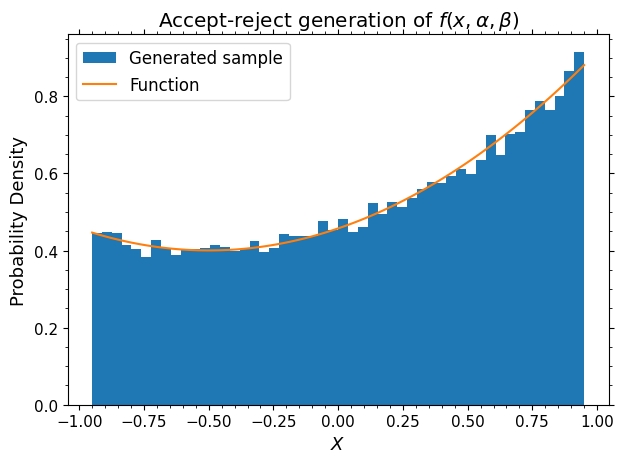

In [2]:
# Import the accept-reject function and plotting utility
from code.accept_reject import accept_reject_1d, check_ok_plot
# Limits of the x-axis for the accept-reject generation:
xrange = [-0.95, 0.95]
# Alpha and beta parameters for the function:
alpha = 0.5
beta = 0.5
# define the d_k function 
dk = lambda k: 1/k*(xrange[1]**k - xrange[0]**k)
# function to generate from:
fx = lambda x: (1+alpha*x+beta*x**2)/(dk(1) + alpha*dk(2) + beta*dk(3))
# Names for the plots
names = r'$f(x,\alpha, \beta)$'

# Run accept-reject generation
dset = accept_reject_1d( fx , xrange, size=50000)
# Plot the results
check_ok_plot( fx , xrange, dset, bins=50, title=r'Accept-reject generation of $f(x,\alpha, \beta)$')

> ### **Question 1 (e):**
> - Now compute your method of moments estimates for $\hat{\alpha}$ and $\hat{\beta}$ from the sample along with the covariance and compare it to the MLE method.

#### **Using scipy to calulcate moments**
$$
\hat{\mu_1} = \frac{1}{n} \sum_{i=1}^n x_i
$$

$$
\hat{\mu_2} = \frac{1}{n} \sum_{i=1}^n x_i^2
$$

---

#### **Calculate the moments**

In [3]:
# MoM estimate
m1_hat = moment(dset, moment=1, center=0)
m2_hat = moment(dset, moment=2, center=0)

# Defining the alpha and beta functions based on the moments
def alpha(m1, m2):
    numerator = (m1*dk(3) - dk(4))*(m2*dk(1)-dk(3)) - (m1*dk(1)-dk(2))*(m2*dk(3)-dk(5))
    denominator = (m1*dk(2) - dk(3))*(m2*dk(3)-dk(5)) - (m1*dk(3)-dk(4))*(m2*dk(2)-dk(4))
    return numerator / denominator


def beta(m1, m2):
    numerator = (m1*dk(1) - dk(2))*(m2*dk(2)-dk(4)) - (m1*dk(2)-dk(3))*(m2*dk(1)-dk(3))
    denominator = (m1*dk(2) - dk(3))*(m2*dk(3)-dk(5)) - (m1*dk(3)-dk(4))*(m2*dk(2)-dk(4))
    return numerator / denominator

# Calculate the MoM estimates for alpha and beta
alpha_hat = alpha(m1_hat, m2_hat)
beta_hat = beta(m1_hat, m2_hat)

# Print the MoM estimates
print(f"Method of Moments estimates: alpha = {alpha_hat:.4f}, beta = {beta_hat:.4f}")


Method of Moments estimates: alpha = 0.4936, beta = 0.5004


#### **Propogate forwards the errors:**
The covariance of the moment estimates is given by

$$
\widehat{\mathrm{cov}}(\hat{\mu}_\alpha, \hat{\mu}_\beta) = \frac{1}{n(n-1)} \sum_{i=1}^{N} (X_i^{\alpha} - \bar{X}_i)(X_i^{\beta} - \bar{X}_i),
$$

which we can then propagate to the covariance on the parameters, $\theta$, using normal error propagation:

$$
\mathrm{cov}(\theta_i, \theta_j) = \sum_{k,l} \frac{\partial \theta_i}{\partial \mu_k} \frac{\partial \theta_j}{\partial \mu_l} \, \mathrm{cov}(\mu_k, \mu_l).
$$

In [4]:
# Calculate the covariance matrix for the MoM estimates
dset = np.array(dset)
N = len(dset)
cov11 = 1/(N*(N-1)) * np.sum( (dset-m1_hat) * (dset-m1_hat) )
cov22 = 1/(N*(N-1)) * np.sum( (dset**2-m2_hat) * (dset**2-m2_hat) )
cov12 = 1/(N*(N-1)) * np.sum( (dset-m1_hat) * (dset**2-m2_hat) )

cov_hat = np.array( [[cov11,cov12],[cov12,cov22]] )

# propagate to parameter estimates
transform = lambda p: np.array( [ alpha(*p), beta(*p) ] )

mom, mom_cov = propagate( transform, [m1_hat, m2_hat], cov_hat )

print("---- METHOD OF MOMENTS ----")
print(tabulate(zip(['alpha','beta'], mom, np.diag(mom_cov)**0.5), headers=['Parameter','Value','Error']))


---- METHOD OF MOMENTS ----
Parameter       Value      Error
-----------  --------  ---------
alpha        0.49364   0.0105442
beta         0.500447  0.0227798


In [5]:
# Now some kind of MLE - iminiut

# Define the density function for the unbinned likelihood
def density(x, alpha, beta):
    N = 1/( dk(1) + alpha*dk(2) + beta*dk(3) )
    return N*(1 + alpha*x + beta*x**2)

# Crease the iminuit unbinned negative log-likelihood object
nll = cost.UnbinnedNLL(dset, density)
# Run the minimization using Minuit
mi = Minuit( nll, alpha=0.5, beta=0.5 )
# 
mi.migrad()
mi.hesse()


print("---- METHOD OF MOMENTS ----")
print(tabulate(zip(['alpha','beta'], mom, np.diag(mom_cov)**0.5), headers=['Parameter','Value','Error']))

print("---- MAXIMUM LIKELIHOOD ---")
print(tabulate(zip(['alpha','beta'], list(mi.values), list(mi.errors)), headers=['Parameter','Value','Error']))



---- METHOD OF MOMENTS ----
Parameter       Value      Error
-----------  --------  ---------
alpha        0.49364   0.0105442
beta         0.500447  0.0227798
---- MAXIMUM LIKELIHOOD ---
Parameter       Value      Error
-----------  --------  ---------
alpha        0.490613  0.0103471
beta         0.488396  0.0219457


> ### **Question 1 (f):**
> - To make sure your method is working, you can use the example dataset provided in the `gitlab` repo under `datasets/mom_data.npy`  
(this is just an array of 2000 points generated from the relevant function).  
> - For this dataset, I found the following (using the upper and lower range values of $a = -0.95$ and $b = 0.95$)
>
> **Method of Moments Estimate:**
>$$
\hat{\alpha} = 0.51 \pm 0.05
>$$
>$$
\hat{\beta} = 0.50 \pm 0.11 
>$$
>
> **Maximum Likelihood Estimate:**
> $$
\hat{\alpha} = 0.53 \pm 0.05 
> $$
> $$
\hat{\beta} = 0.54 \pm 0.11
> $$

In [6]:
# Rerun on the dataset provided in the gitlab repo
# Load the dataset
dset_loaded = np.load('datasets/mom_data.npy')
# Calculate the MoM estimates for alpha and beta
m1_hat = moment(dset_loaded, moment=1, center=0)
m2_hat = moment(dset_loaded, moment=2, center=0)
# Calculate the MoM estimates for alpha and beta
alpha_hat = alpha(m1_hat, m2_hat)
beta_hat = beta(m1_hat, m2_hat)

# Calculate the covariance matrix for the MoM estimates
N = len(dset_loaded)
cov11 = 1/(N*(N-1)) * np.sum( (dset_loaded-m1_hat) * (dset_loaded-m1_hat) )
cov22 = 1/(N*(N-1)) * np.sum( (dset_loaded**2-m2_hat) * (dset_loaded**2-m2_hat) )
cov12 = 1/(N*(N-1)) * np.sum( (dset_loaded-m1_hat) * (dset_loaded**2-m2_hat) )
cov_hat = np.array( [[cov11,cov12],[cov12,cov22]] )
# propagate to parameter estimates
mom, mom_cov = propagate( transform, [m1_hat, m2_hat], cov_hat )

# Now some kind of MLE - iminiut
# Crease the iminuit unbinned negative log-likelihood object
nll = cost.UnbinnedNLL(dset, density)
# Run the minimization using Minuit
mi = Minuit( nll, alpha=0.5, beta=0.5)
mi.migrad()
mi.hesse()

print("---- METHOD OF MOMENTS ----")
print(tabulate(zip(['alpha','beta'], mom, np.diag(mom_cov)**0.5), headers=['Parameter','Value','Error']))

print("---- MAXIMUM LIKELIHOOD ---")
print(tabulate(zip(['alpha','beta'], list(mi.values), list(mi.errors)), headers=['Parameter','Value','Error']))


---- METHOD OF MOMENTS ----
Parameter       Value      Error
-----------  --------  ---------
alpha        0.511264  0.0523103
beta         0.499594  0.113603
---- MAXIMUM LIKELIHOOD ---
Parameter       Value      Error
-----------  --------  ---------
alpha        0.490613  0.0103471
beta         0.488396  0.0219457


> ## **Question 2:**
> If 1000 measurements are grouped in 25 bins and fitted to a curve which is the sum of an arbitrary Gaussian on an arbitrary flat background, how many degrees of freedom are there?

## **Solution**
**In the context of curve fitting, degrees of freedom:**

$\text{Degrees of Freedom} = \text{Number of Data Points (bins)} - \text{Number of Fitted Parameters}$

- There are 25 bins. 
- A Gaussian has 2 shape parameters and there is one scale or “height” parameter for how much of the Gaussian there is. 
- The background has no shape parameters (it is flat) but still has an overall height parameter. 
- Thus the total is 25 − 3 − 1 = 21.


> ### **Question 3 (a):**
> Below are the number of neutrino events detected in 10 second intervals by the Irvine-Michigan-Brookhaven experiment on 23rd February 1987.  
> For context, the “background” should give a Poisson distribution of neutrino counts, but some kind of “signal” producing excess neutrinos (*e.g.* a supernova like SN1987a which was discovered around this time) would provide an excess of neutrinos in a short interval.
> | No. of events       | 0    | 1    | 2   | 3  | 4 | 5 | 6 | 7 | 8 | 9 |
> |---------------------|------|------|-----|----|---|---|---|---|---|---|
> | No. of intervals    | 1042 | 860  | 307 | 78 |15 | 3 | 0 | 0 | 0 | 1 |

> - Assuming these are described by a Poisson distribution (with a floating mean), find an estimate of the value of the mean, and then compute the $\chi^2$ and $p$-value of this particular set of observations?

#### **Poisson Distribution**
The Poisson distribution is defined as:
$$ 
P(k; \lambda) = \frac{\lambda^k e^{-\lambda}}{k!} 
$$
where
- $\lambda$ is the average rate of occurrence of the event in a fixed interval of time or space
- $k$ is the number of occurrences.

Mean number of counts per interval: 0.7771
Chi2: 3313.2395174607573
p-value: 0.0


(0.1, np.float64(1522.9069741778321))

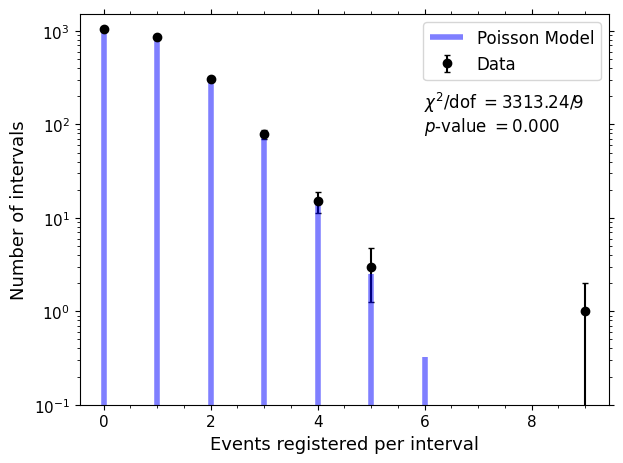

In [7]:
# Dataset for the Poisson distribution
nevs    = np.arange(10)
ncounts= np.array( [1042, 860, 307, 78, 15, 3, 0, 0, 0, 1] )

# Total number of intervals
tot_counts = np.sum(ncounts)
# Total number of counts
wtd_counts = np.sum( nevs*ncounts)
# Calculate the mean number of counts per interval
mean = wtd_counts / tot_counts
print(f"Mean number of counts per interval: {mean:.4f}")


# Fpr a total number of counts, the Poisson distribution for each interval is given by:
prd_counts = tot_counts * poisson.pmf( nevs, mean )
# Calculate the chi-squared value
chisq = np.sum( (ncounts - prd_counts)**2 / prd_counts )
pval = chi2.sf( chisq, len(prd_counts)-1 )
print('Chi2:', chisq)
print('p-value:', pval)

fig, ax = plt.subplots()
ax.errorbar( nevs, ncounts, ncounts**0.5, fmt='ko', label='Data' )
ax.vlines( nevs, 0, tot_counts*poisson.pmf( nevs, mean ), colors='b', lw=4, alpha=0.5, label='Poisson Model' )
ax.set_yscale('log')
ax.set_xlabel('Events registered per interval')
ax.set_ylabel('Number of intervals')
ax.legend()

ax.text(0.65, 0.76, f'$\chi^2/$dof $= {chisq:4.2f}/{len(nevs)-1}$', transform=ax.transAxes)
ax.text(0.65, 0.70, f'$p$-value $= {pval:5.3f}$', transform=ax.transAxes )
ax.set_ylim(bottom=1e-1)

> ### **Question 3 (b):**
> - Now compute the same but excluding the data in the last bin (*i.e.* excluding the interval with 9 events)?

Mean number of counts per interval: 0.7735
Chi2: 3.2448001271179256
p-value: 0.9180690063551703


(0.1, np.float64(1504.936872434782))

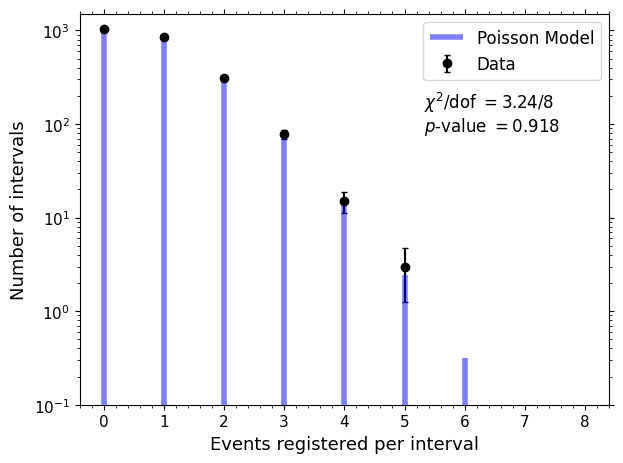

In [8]:
# Dataset for the Poisson distribution Minus the last bin
nevs_remove    = nevs[:-1]
ncounts_remove = ncounts[:-1]

# Total number of intervals
tot_counts = np.sum(ncounts_remove)
# Total number of counts
wtd_counts = np.sum( nevs_remove*ncounts_remove )
# Calculate the mean number of counts per interval
mean = wtd_counts / tot_counts
print(f"Mean number of counts per interval: {mean:.4f}")


# Fpr a total number of counts, the Poisson distribution for each interval is given by:
prd_counts = tot_counts * poisson.pmf( nevs_remove, mean )
# Calculate the chi-squared value
chisq = np.sum( (ncounts_remove - prd_counts)**2 / prd_counts )
pval = chi2.sf( chisq, len(prd_counts)-1 )
print('Chi2:', chisq)
print('p-value:', pval)

fig, ax = plt.subplots()
ax.errorbar( nevs_remove, ncounts_remove, ncounts_remove**0.5, fmt='ko', label='Data' )
ax.vlines( nevs_remove, 0, tot_counts*poisson.pmf( nevs_remove, mean ), colors='b', lw=4, alpha=0.5, label='Poisson Model' )
ax.set_yscale('log')
ax.set_xlabel('Events registered per interval')
ax.set_ylabel('Number of intervals')
ax.legend()

ax.text(0.65, 0.76, f'$\chi^2/$dof $= {chisq:4.2f}/{len(nevs_remove)-1}$', transform=ax.transAxes)
ax.text(0.65, 0.70, f'$p$-value $= {pval:5.3f}$', transform=ax.transAxes )
ax.set_ylim(bottom=1e-1)

> ### **Question 3 (c):**
> Use these results to justify whether this data describes a Poisson background only or not.

- Shown by the graphs and increase in p-values
- The conclusion of course is that a simple Poisson only background cannot explain this occurence of an intervals countaining 9 neutrinos events.
- The conclusion ofthat is an observation has been made of some object which for a short period was emitting a high-neutrino flux. 
- This was the supervnova S1987A.

> ### **Question 4 (Not Included 2025):**
> Explain with a short proof why the Neyman-Pearson test is the statistically most powerful hypothesis test.

### **Solution**

#### **Recalling the Neyman Pearson Lemma:**
The most powerful test between two hypotheses is constructed from the likelihood ratio between them:
$$
T = -2 \ln \left( \frac{L(X \mid H_0)}{L(X \mid H_1)} \right),
$$

#### **What does it mean to be a `powerful' test:**

![Plot](images/alphabeta.png)


- $\alpha$ is the Type I error rate:
	- It’s the probability of rejecting the null hypothesis $H_0$ when it is actually true.

$$
\alpha = \int_{X_0}^{\infty} p(X; \theta_0) \, dX
$$

- $(1- \beta)$ is the Type II error rate:
    - It’s the probability of accepting the null hypothesis H_0 when it is actually false 
    - Note convention used $\beta vs 1-\beta$

$$
\beta = \int_{X_0}^{\infty} p(X; \theta_1) \, dX 
$$

**Best Test:**
For a given $\alpha$ we wish to minimise $(1- \beta)$ ie maximise $\beta$:
- Assuming that $\theta$ is some continuous parameter which differentiates between the null and alternate hypotheses

$$
\beta = \int_{X_0}^{\infty} p(X; \theta_1) \, dX 
$$

$$
\phantom{\beta}
= \int_{X_0}^{\infty} \frac{p(X; \theta_1)}{p(X; \theta_0)} p(X; \theta_0) \, dX
= \mathbb{E} \left[ \frac{p(X; \theta_1)}{p(X; \theta_0)} \right]
$$

Thus we see that in order to maximise $\beta$ we have to maximise the expectation value on the right, which is done with test statistics of the form of the likelihood ratio.


> ### **Question 4 (a):**
> Imagine a measurement of four parameters yields the following result:
> $$
x^+ = (-9.3 \pm 8.2) 
> $$
> $$
y^+ = (-1.3 \pm 8.4)
> $$
> $$
x^- = (5.7 \pm 8.2) 
> $$
> $$
y^- = (6.5 \pm 8.3)
> $$
> with the following correlation matrix:
> |         | $x^+$ | $y^+$ | $x^-$ | $y^-$ |
> |---------|-------|-------|-------|-------|
> | $x^+$   | 1     | -0.1  | -0.05 | 0.1   |
> | $y^+$   | -0.1  | 1     | 0.1   | -0.05 |
> | $x^-$   | -0.05 | 0.1   | 1     | 0.1   |
> | $y^-$   | 0.1   | -0.05 | 0.1   | 1     |

> - Assuming the observations of $(x^\pm, y^\pm)$ are multivariate normally distributed, use the ML method to estimate the values, uncertainties, and correlations of the parameters $(\gamma, r, \delta)$ where:
> $$
x^\pm = r \cos(\delta \pm \gamma) 
> $$
> $$
y^\pm = r \sin(\delta \pm \gamma) 
> $$


### **Visulising the data I have here:** 

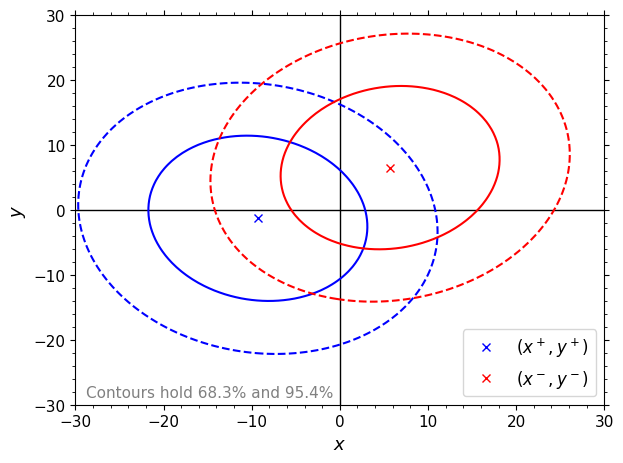

In [9]:
# Writing out the data
names = [ 'xp', 'yp', 'xm', 'ym' ]
titles = [ '$x^+$', '$y^+$', '$x^-$', '$y^-$' ]
values = np.array( [ -9.3, -1.3, 5.7, 6.5 ] )
errors = np.array( [  8.2,  8.4, 8.2, 8.3 ] )
# Diagonal matrix of errors
D = np.diag(errors)

corr = np.array([
    [  1   , -0.1 , -0.05,   0.1 ],
    [ -0.1 ,  1   ,  0.1 ,  -0.05],
    [ -0.05,  0.1 ,  1   ,   0.1 ],
    [  0.1 , -0.05,  0.1 ,   1   ] ] )

# Covariance matrix
cova = D @ corr @ D

# Construct the multivariate normal model
model = mvn( mean=values, cov=cova )

# Function to draw the 2D polar plot
def draw_2d():
    fig, ax = plt.subplots()

    ax.axvline( 0, c='k', lw=1)
    ax.axhline( 0, c='k', lw=1)

    mvnp = mvn( mean=values[:2], cov=cova[:2,:2] )
    mvnm = mvn( mean=values[2:], cov=cova[2:,2:] )

    x = np.linspace(-30,30,100)
    y = np.linspace(-30,30,100)

    X, Y = np.meshgrid(x,y)

    pos = np.dstack([X,Y])
    
    n2llp = -2 * ( mvnp.logpdf( pos ) - mvnp.logpdf( values[:2] ) )
    n2llm = -2 * ( mvnm.logpdf( pos ) - mvnm.logpdf( values[2:] ) )
    
    sigmas = np.array( [1, 2] )
    levels = chi2.ppf( chi2.cdf( sigmas**2, 1), 2 ) 
    ax.contour( X, Y, n2llp, colors='b', linestyles=['-','--'], levels=levels )
    ax.contour( X, Y, n2llm, colors='r', linestyles=['-','--'], levels=levels )

    ax.plot( *values[:2], 'bx', label='$(x^+, y^+)$' )
    ax.plot( *values[2:], 'rx', label='$(x^-, y^-)$' )

    ax.text(0.02, 0.02, 'Contours hold 68.3% and 95.4%', transform=ax.transAxes, fontsize=11, color='0.5' )

    ax.legend(loc='lower right')

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

# Draw the 2D polar plot
draw_2d()


### **Defining the tranform and minimising using Minuit**
- Calculate the estimates and their corrolation function

In [10]:
# The log-likelihood of the observed data 
ll_min = model.logpdf( values )

# Define the function to calculate the negative twice delta log-likelihood of the tranfromed parameters
def n2ll( gamma, r, delta ):
    g = np.radians(gamma)
    d = np.radians(delta)
    xp = r*np.cos(d+g)
    yp = r*np.sin(d+g)
    xm = r*np.cos(d-g)
    ym = r*np.sin(d-g)

    ll_here = model.logpdf( [xp, yp, xm, ym] )

    n2ll = -2*(ll_here - ll_min)

    return n2ll

# Run the minimization using Minuit
mi = Minuit( n2ll, gamma=100, r=1, delta=150 )
mi.limits['gamma'] = (0,180)
mi.limits['delta'] = (0,180)
mi.limits['r'] = (0,25)

mi.migrad()
mi.hesse()
mi.minos()
print(mi)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.00379                    │              Nfcn = 368              │
│ EDM = 2.82e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬─────

> ### **Question 4 (b):**
> - Make a plot of the profile likelihood scan for the parameter $r$.  
> - Do you see any issues here?  
> - Can you use this to make an estimate of the uncertainty on your estimate of $r$?  
> - What about if you want to quote the interval containing 95%?

### **Drawing 1D profiles of each parameter**

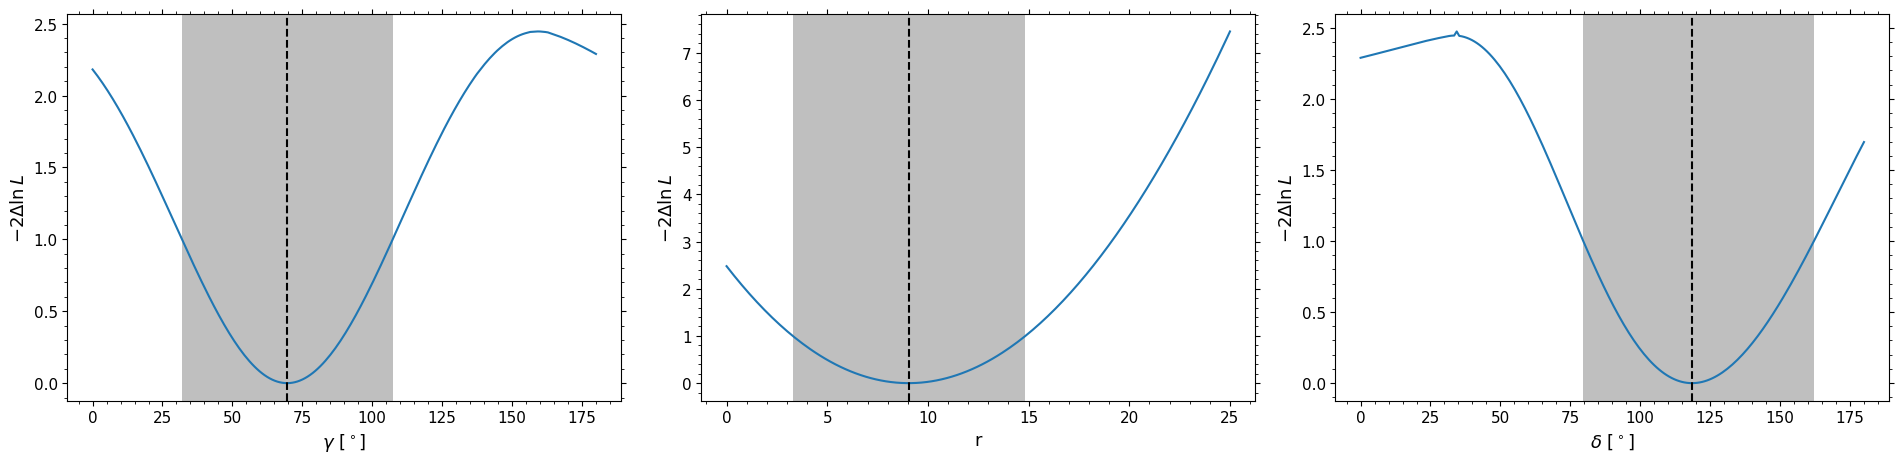

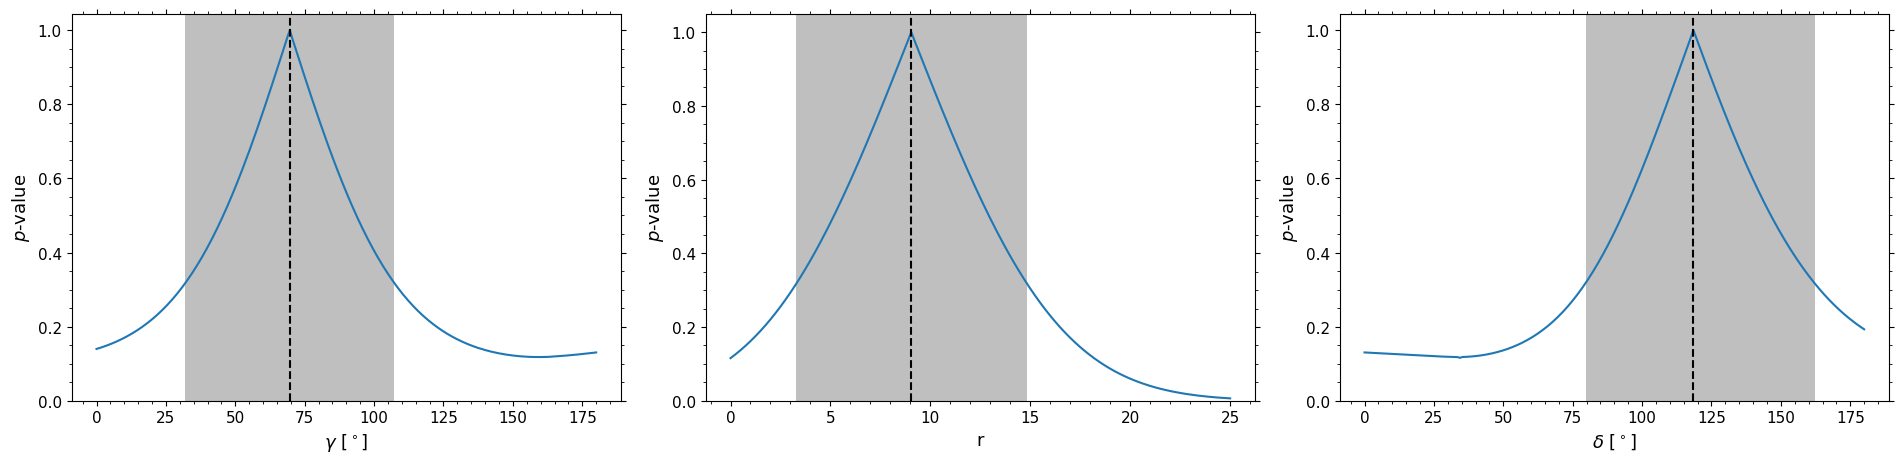

In [11]:
def draw_1d_profile( mi, par, title, ax=None, convert=False ):
    """
    Plot the 1D profile likelihood (or p-value) for a given parameter from a Minuit fit.

    Parameters
    ----------
    mi : iminuit.Minuit
        A Minuit object that has been fitted to data using .migrad(), .hesse(), and optionally .minos().
        
    par : str
        The name of the parameter to profile.
        
    title : str
        Label for the x-axis (e.g. formatted in LaTeX).
        
    ax : matplotlib.axes._axes.Axes, optional
        A matplotlib Axes object to draw on. If None, the current active axis will be used.
        
    convert : bool, default False
        If True, the y-axis is converted from -2ΔlnL to p-values using a chi-squared survival function with 1 d.o.f.
    """
    ax = ax or plt.gca()

    # Using the Minuit profile function to get the 1D profile
    # Uses the Mi limits of the parameter to bound the profile
    x, y, valid = mi.mnprofile(par, subtract_min=True, bound=mi.limits[par], size=200)
    if convert:
        y = chi2.sf(y,1)
    ax.plot( x[valid], y[valid] )

    ax.axvspan( mi.values[par]+mi.merrors[par].lower, mi.values[par]+mi.merrors[par].upper, fc='0.5', alpha=0.5 )
    ax.axvline( mi.values[par], c='k', ls='--' )

    ax.set_xlabel(title)
    ax.set_ylabel('$-2\Delta\ln L$')
    if convert:
        ax.set_ylabel('$p$-value')

    if convert:
        ax.set_ylim(bottom=0)

fig, axes = plt.subplots(1,3, figsize=(19.2, 4.8))
for par, title, ax in zip(['gamma','r','delta'], ['$\gamma$ [$^\circ$]', 'r', '$\delta$ [$^\circ$]'], axes.flatten()):
    draw_1d_profile( mi, par, title, ax=ax )

fig, axes = plt.subplots(1,3, figsize=(19.2, 4.8))
for par, title, ax in zip(['gamma','r','delta'], ['$\gamma$ [$^\circ$]', 'r', '$\delta$ [$^\circ$]'], axes.flatten()):
    draw_1d_profile( mi, par, title, ax=ax, convert=True )

- The profile likelihood looks fine for r (depending on where you run the limits to). 
- The problem is you hit a physical boundary at 0 and thus cannot quote an interval out to 95%.

> ### **Question 4 (c):**
> - Can you compute (or at least explain how you would compute) the coverage of your interval on $\gamma$?

## **Solution**
- To compute the coverage you would through toys (pseduo-experiments) from the best-fit point. 
---

#### **Step 1: Use the Best-Fit Point**
- Take your best-fit values from your actual data (e.g. $\hat{\gamma}$, $\hat{r}$, $\hat{\delta}$).
- Assume those are the **true** values (just for the purpose of the simulation).


#### **Step 2: Generate Synthetic Datasets**
- Simulate many fake datasets (**toys**) using those “true” values.
- These datasets are **randomly generated** but follow the same **statistical model** and **uncertainty structure** as the original data.

#### **Step 3: Refit Each Toy Dataset**
- For each toy dataset:
  - Run the **same fit** you used originally.
  - Extract the estimated parameter (e.g. fitted $\gamma$).
  - Also extract the **confidence interval** for $\gamma$.


#### **Step 4: Check Whether the True Value Is Inside**
- For each fit, check if the **true value** (from step 1) is inside the estimated confidence interval (e.g. 90% CI).


#### **Step 5: Compute Coverage**
- After many toys, compute the **fraction of intervals that included the true value**.
  - If you used **90% intervals** and only ~80% of them actually included the true value → you are **undercovering**.
  - If **95%** included the true value → you are **overcovering**.

> ### **Question 4 (d):**
> - Explain how you could set an upper limit on the parameter $r$.

### **Solution**
- r is near a physical boundary
- Must use: 
#### **Fieldman Cousins**
1. **Fit the Actual Data**
- You fit your model (say, for a parameter $\mu$) using maximum likelihood estimation (MLE).
- This gives you a best-fit point: $ \hat{\mu} $
- You also compute the log-likelihood at that point:
$$ -2 \ln L(\hat{\mu}) $$
- This is your reference point.

---

2. **Scan Test Values**  
- Pick a value of $\mu$, say $\mu_0$, that you want to test.
- Compute the log-likelihood at that point:
$$ -2 \ln L(\mu_0) $$
- Compute the test statistic (how worse is $\mu_0$ compared to the best fit):
$$
T = -2 \ln L(\mu_0) + 2 \ln L(\hat{\mu}) = -2 \Delta \ln L(\mu_0)
$$
- Note: 
  - As  $L(\mu_0) \leq L(\hat{\mu})$: $T \geq 0$
  - Large T - poor comparitive fit vs best case

---

3. **Generate Pseudo-Experiments (Toys)**  
   - Simulate many toy datasets under the assumption that $\mu = \mu_0$.
   - For each toy:
     - Fit the toy to get its best-fit value $\hat{\mu}_i$, and compute:  
       $$ -2 \ln L(\hat{\mu}_i) $$
     - Also compute the likelihood at the fixed $\mu_0$:  
       $$ -2 \ln L(\mu_0)_i $$
     - Define the toy’s test statistic:  
       $$ T_i = -2 \ln L(\mu_0)_i + 2 \ln L(\hat{\mu}_i) = -2 \Delta \ln L(\mu_0)_i $$
      - This says:
        - We know $\mu_0$ is correct, what is the spread in $T_i$
        - We can then compare this spread in $T_i$ with the value of T we achieved
---

4. **Compute p-Value / Confidence Level**  
   - The confidence level (1 - CL) at $\mu_0$ is the fraction of toy datasets where:  
     $$ T_i > T $$
    

- If $T_i > T$ rarely (i.e. $p$ is small):
  - Your data looks very unlikely under the assumption that $\mu_0$ is true.
  - You can reject $\mu_0$ at confidence level $1 - p$.
- If $T_i > T$ often (i.e. $p$ is large):
  - Your data looks typical or better than most toy datasets generated under $\mu_0$.
  - You cannot reject $\mu_0$ — it’s consistent with the data.

> ### **Question 5:**
> Imagine a set of $N$ counting experiments which all determine an estimated number of background, $b_i$, an estimated number of signal, $s_i$, and observe $d_i$ candidates in data.  
> - Write down a mathematical expression for (the most) powerful test-statistic in this case.

### **Solution**

The **Poisson likelihood** for observing a count $ d_i $ given an expected mean $ \lambda_i $ is:

$$
\text{Poiss}(d_i; \lambda_i) = \frac{e^{-\lambda_i} \lambda_i^{d_i}}{d_i!}
$$

According to the **Neyman–Pearson lemma**, the most powerful test between two hypotheses is based on the **likelihood ratio**:

$$
\Lambda = \frac{L_1}{L_0}
$$

Or in logarithmic form:

$$
\ln \Lambda = \ln\left( \frac{L_1}{L_0} \right)
$$

Where:
- $ L_1 $: likelihood under signal + background (**alternative hypothesis - $\lambda = s_i + b_i$**)
- $ L_0 $: likelihood under background-only (**null hypothesis - $\lambda = b_i$**)

---

### **Poisson Log-Likelihood Ratio Derivation**

Given $ N $ independent bins, each following a Poisson distribution, the likelihood ratio is:

$$
\frac{L_1}{L_0} = \prod_{i=1}^{N} \frac{\text{Poiss}(d_i; s_i + b_i)}{\text{Poiss}(d_i; b_i)}
$$

$$
= \prod_{i=1}^{N} \frac{e^{-(s_i + b_i)} (s_i + b_i)^{d_i}}{d_i!} \bigg/ \frac{e^{-b_i} b_i^{d_i}}{d_i!}
$$

$$
= \prod_{i=1}^{N} e^{-s_i} \left( \frac{s_i + b_i}{b_i} \right)^{d_i}
$$

$$
\ln \left( \frac{L_1}{L_0} \right)
= \sum_{i=1}^{N} d_i \ln(s_i + b_i) - s_i - d_i \ln(b_i)
$$

## **Question 6**
### a) Projecting a 1D measurement onto a 2D plane

First up we assume we've made a measurement of some observable $\beta = (22 \pm 4)^\circ$.
This observable is related to some other parameters of interest, $(x,y)$, via the relation:

$$
\tan \beta = \frac{ y }{ 1-x }
$$


In [12]:
# define the measured value and error and some useful functions defining
# beta in terms of x and y, and
# y in terms of x and beta
beta_meas = (22, 4)

def beta_func(x, y):
    return np.degrees( np.arctan2(y, 1-x) )

def y_func(x, beta):
    return (1 - x) * np.tan(np.radians(beta))

It's pretty straightforward to plot a line in $(x,y)$ space which represents the value of $\beta$ we measured.

We can also draw equivalent lines at the $\pm 1 \sigma$ values to show where the contour containing $1\sigma$ is. Given this is a 1D measurement this should be the one that contains 68.3% but we will explicitly check that via a couple of others methods too.

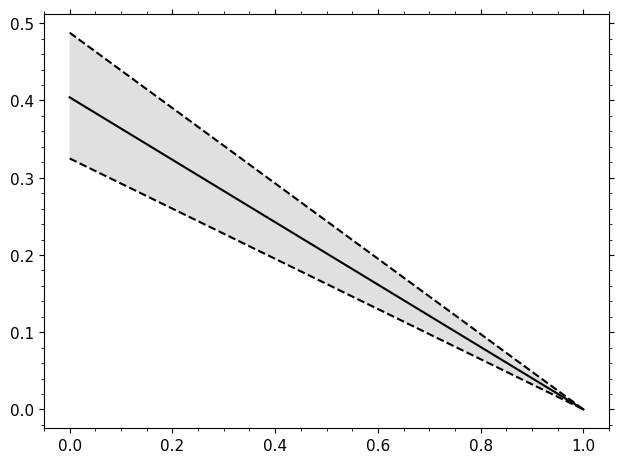

In [13]:
x = np.linspace(0, 1, 400)

plt.plot(x, y_func(x, beta_meas[0]), c='k')
plt.fill_between(x, y_func(x, beta_meas[0]-beta_meas[1]), y_func(x, beta_meas[0]+beta_meas[1]), fc='0.4', alpha=0.2)
plt.plot(x, y_func(x, beta_meas[0] - beta_meas[1]), c='k', ls='--')
plt.plot(x, y_func(x, beta_meas[0] + beta_meas[1]), c='k', ls='--')

Now we'll compare this to drawing contours in the log-likelihood. 

We'll draw as colours with `contourf` but then also again with `contour` with the level set to $-2\Delta \ln L=1$.

Note that if we wanted the $2\sigma$ contour (i.e. the one which contains 95.4\%) then we would need to draw it at $-2\Delta \ln L = 2^2 = 4$ because we are using Wilks' theorem to approximate the $-2\Delta \ln L$ as being $\chi^2$ distributed.

<a list of 3 text.Text objects>

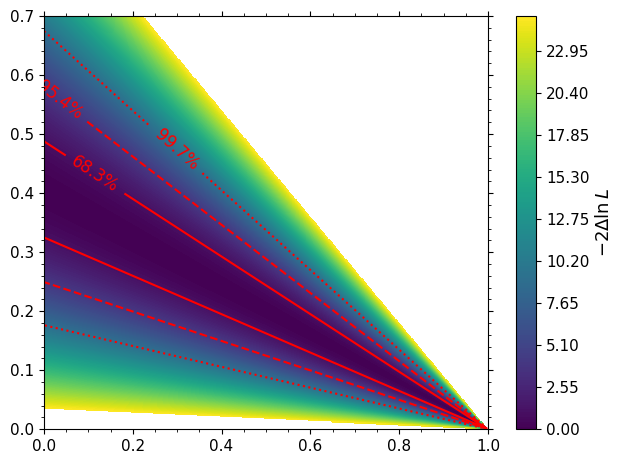

In [14]:
# make a grid
y = np.linspace(0, 0.7, 400)
X, Y = np.meshgrid(x, y)

# compute the value of beta each point on the grid corresponds to
beta_pred = beta_func(X, Y)

# compute -2DLL (note I can get the minimum from the central value)
nll_min = norm.logpdf( beta_meas[0], beta_meas[0], beta_meas[1] )
nll_grid = norm.logpdf( beta_pred, beta_meas[0], beta_meas[1] )

n2ll = -2 * (nll_grid - nll_min)
# draw the filled contour (masking large values so the colour range spans appropriate colours)
n2ll_plot = n2ll.copy()
n2ll_plot[n2ll_plot > 25] = None
cf = plt.contourf(X, Y, n2ll_plot, levels=200, vmin=0, vmax=25)
cb = plt.colorbar(cf)
cb.set_label('$-2\Delta \ln L$')

# draw the contour lines corresponding to 68, 95, 99 CL
levels = [1,4,9]
labels = [f'{100*chi2.cdf(level,1):4.1f}%' for level in levels ]
cf = plt.contour(X, Y, n2ll, levels=[1,4,9], colors='r', linestyles=['-','--',':'])
plt.clabel(cf, inline=True, colors='r', fmt={a: b for a, b in zip(levels, labels)})

So now we check if this agrees with what we plotted before, and it does!

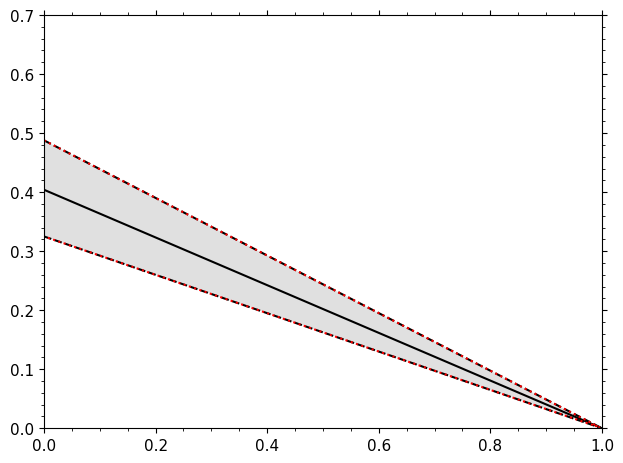

In [15]:
plt.plot(x, y_func(x, beta_meas[0]), c='k')
plt.fill_between(x, y_func(x, beta_meas[0]-beta_meas[1]), y_func(x, beta_meas[0]+beta_meas[1]), fc='0.4', alpha=0.2)
plt.plot(x, y_func(x, beta_meas[0] - beta_meas[1]), c='k', ls='--')
plt.plot(x, y_func(x, beta_meas[0] + beta_meas[1]), c='k', ls='--')
plt.contour(X, Y, n2ll, levels=[1], colors='r', linestyles=[':'])

In [16]:
# generate a large sample of random beta values
betas = np.random.normal(beta_meas[0], beta_meas[1], size=50000)

# for each compute the equivalent "line" in x, y space
y_samples = []
for beta in betas:
    yv = (1 - x) * np.tan( np.radians(beta) )
    y_samples.append(yv)

y_samples = np.asarray(y_samples)

# this should now be an array (n_samples, n_points)
# so for each n_points find the spread over y from n_samples
sigma = 1 # 68.3%
lower_quantile = 100*chi2.sf(sigma**2, 1) / 2
upper_quantile = 100 - lower_quantile
lower_band = np.percentile(y_samples, lower_quantile, axis=0)
upper_band = np.percentile(y_samples, upper_quantile, axis=0)

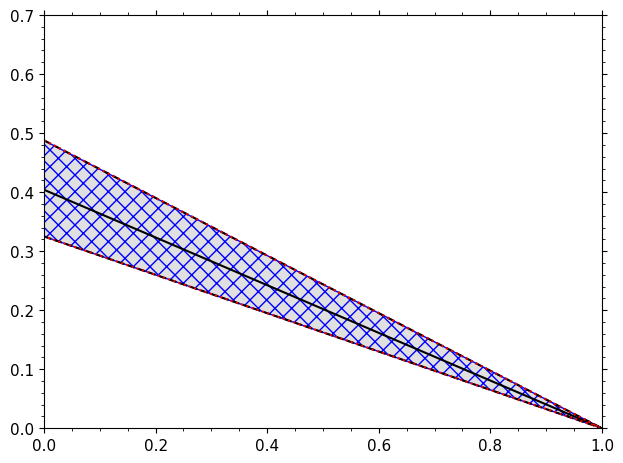

In [17]:
plt.plot(x, y_func(x, beta_meas[0]), c='k')
plt.fill_between(x, y_func(x, beta_meas[0]-beta_meas[1]), y_func(x, beta_meas[0]+beta_meas[1]), fc='0.4', alpha=0.2)
plt.plot(x, y_func(x, beta_meas[0] - beta_meas[1]), c='k', ls='--')
plt.plot(x, y_func(x, beta_meas[0] + beta_meas[1]), c='k', ls='--')
plt.contour(X, Y, n2ll, levels=[1], colors='r', linestyles=[':'])
plt.fill_between(x, lower_band, upper_band, fc='none', ec='b', hatch='xx')

### What have we learnt here?

We have learnt that for a 1D measurement (where there is one degree of freedom) then $-2\Delta\ln L$ follows a $chi^2$ distribution with **1 degree of freedom** regardless of whether it is plotted in a higher dimensional space.

### b) Now consider a 2D measurement

Here we measure two new parameters $r = 0.40 \pm 0.05$ and $\theta = (60 \pm 7)^\circ$ (with a correlation of 0.4) which are related to $x$ and $y$ via

$$
r^2 = x^2 + y^2 \quad \text{and} \quad \tan\theta = \frac{y}{x}
$$

Notice below how non-Gaussian the likelihood looks in $x$ and $y$ because of the non-linear relationships between $(r, \theta)$ and $(x,y)$.

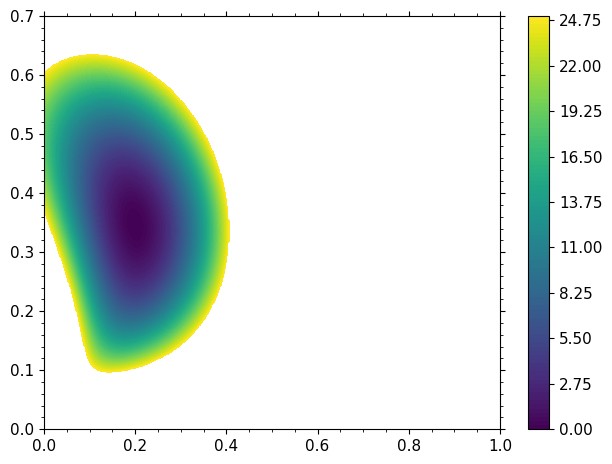

In [19]:
# write down the measured values, errs and correlation
r_meas = (0.40, 0.05)
theta_meas = (60, 7)
mean = [r_meas[0], theta_meas[0]]
errors = [r_meas[1], theta_meas[1]]
corr = 0.4
cov = [ [errors[0]**2, corr*errors[0]*errors[1]] ,
        [corr*errors[0]*errors[1], errors[1]**2] ]

# define the relationships
def r_func(x, y):
    return np.sqrt(x**2 + y**2)

def theta_func(x, y):
    return np.degrees(np.arctan2(y, x))

# now do the equivalent log likelihood in 2D


r_pred = r_func(X,Y)
theta_pred = theta_func(X,Y)
grid_point_pred = np.column_stack((r_pred.flatten(), theta_pred.flatten()))

nll_min = mvn.logpdf(mean, mean, cov)
nll_point = mvn.logpdf(grid_point_pred, mean, cov)
nll_point = nll_point.reshape(X.shape)

n2ll = -2 * (nll_point - nll_min)

# mask points with large values
n2ll_plot = n2ll.copy()
n2ll_plot[n2ll_plot>25] = None

cb = plt.contourf(X, Y, n2ll_plot, levels=100)
plt.colorbar(cb)

So the question now is where do we draw the contours and what probability content do they represent?


If we follow what we just did for the 1D measurement case we would still draw at $-2\Delta \ln L$ values of $[1,4,9]$. We of course can do that but do these contain 68.3%, 95.4%, 99.7%? In this case they don't (as we'll demonstrate with bootstrapping in a moment) because it's a 2D measurement (there are **two degrees of freedom**).

So where should we draw the contours? For this we can exploit the $\chi^2$ distribution properties (and continue to work under the assumption that Wilks' theorem holds - i.e. that $-2\Delta ln L$ is $\chi^2$ distributed but now with 2 d.o.f.).


In [20]:
# say that we want 1, 2, 3 sigmas
sigmas = np.array( [1, 2, 3] )
print("std dev", sigmas)

# this corresponds to a n2ll value of sigma^2 in 1d
n2ll_1d = sigmas**2
print("N2LL (1D):", n2ll_1d)

# the chi2 distribution tells us the probability content
p_content_1d = chi2.cdf(n2ll_1d, 1)
print("   Prob Content (1D):", p_content_1d)

# and notice that the probability content in 2D is not the same
p_content_2d = chi2.cdf(n2ll_1d, 2)
print("   Prob Content (2D):", p_content_2d)

# to get the equivalent value of N2LL in 2D for the probability content
# in 1D using the inverse of the cdf
n2ll_2d = chi2.ppf(p_content_1d, 2)
print("N2LL (2D):", n2ll_2d)

# and to be explicit show what the probability content of these n2ll values are
p_content_1d = chi2.cdf(n2ll_2d, 1)
print("   Prob Content (1D):", p_content_1d)

p_content_2d = chi2.cdf(n2ll_2d, 2)
print("   Prob Content (2D):", p_content_2d)

std dev [1 2 3]
N2LL (1D): [1 4 9]
   Prob Content (1D): [0.68268949 0.95449974 0.9973002 ]
   Prob Content (2D): [0.39346934 0.86466472 0.988891  ]
N2LL (2D): [ 2.29574893  6.18007431 11.82915808]
   Prob Content (1D): [0.87027138 0.98708031 0.9994169 ]
   Prob Content (2D): [0.68268949 0.95449974 0.9973002 ]


So now I'll remake the plot above overlaying the contours but now drawn at $-2\Delta \ln L = [2.30, 6.18, 11.83]$

<a list of 3 text.Text objects>

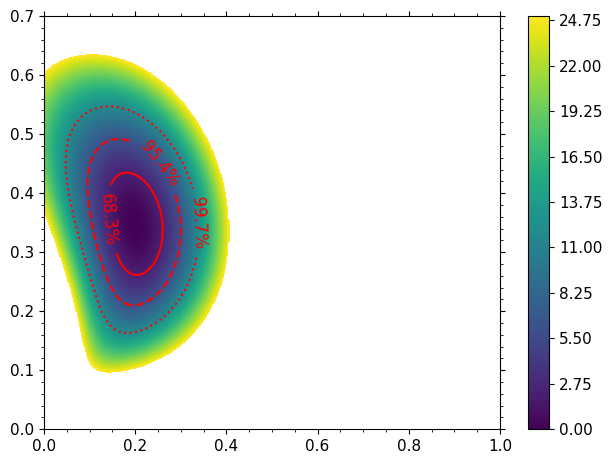

In [21]:
cb = plt.contourf(X, Y, n2ll_plot, levels=100)
plt.colorbar(cb)

cf = plt.contour(X, Y, n2ll, levels=n2ll_2d, colors='r', linestyles=['-','--',':'] )
plt.clabel(cf, inline=True, colors='r', fmt={a: b for a, b in zip(n2ll_2d, labels)})

### Check with the toys

need to solve the simultaneous equation to get $x$, $y$ values from $r$, $\theta$ values:

$$
x = r \cos(\theta) \quad \text{and} \quad y = r \sin(\theta)
$$

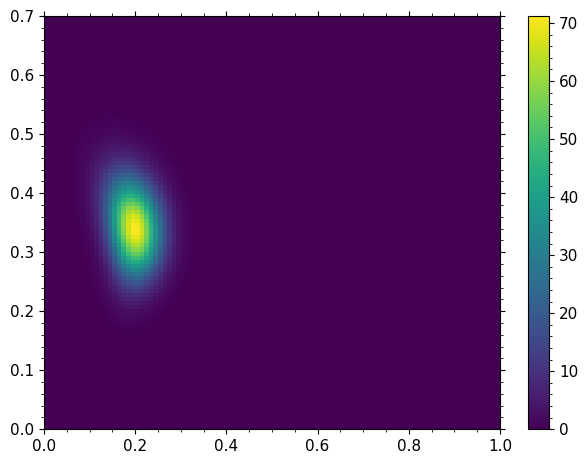

In [22]:
# generate a large sample of random r and theta values
rvs = mvn.rvs(mean, cov, size=20000000)

r_sample = rvs[:,0]
theta_sample = rvs[:,1]
x_sample = r_sample * np.cos( np.radians(theta_sample) )
y_sample = r_sample * np.sin( np.radians(theta_sample) )

nh, xe, ye, im = plt.hist2d(x_sample, y_sample, bins=100, range=[(0,1),(0,0.7)], density=True)
plt.colorbar(im)

<a list of 3 text.Text objects>

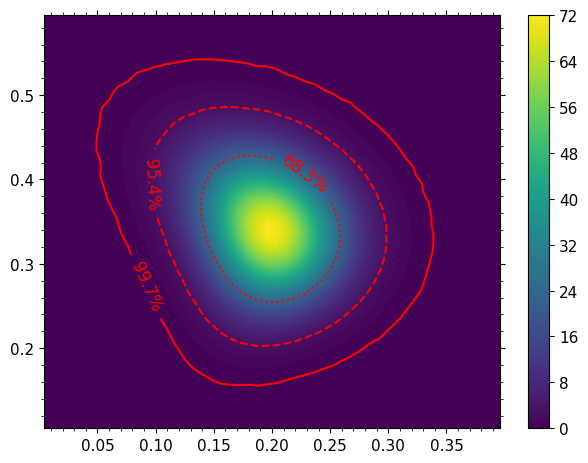

In [23]:
# plot the sample and draw the contours using the cumalitive density
nh, xe, ye = np.histogram2d(x_sample, y_sample, bins=50, range=[(0,0.4),(0.1,0.6)], density=True)
cx = 0.5 * (xe[1:] + xe[:-1])
cy = 0.5 * (ye[1:] + ye[:-1])
Xh, Yh = np.meshgrid(cx, cy)

# Get cdf of histogram (helps compute where the contours containing X% are)
nh_flat = nh.flatten()
nh_sort = np.sort(nh_flat)[::-1]
cdf = np.cumsum(nh_sort)
cdf /= cdf[-1]

# find density levels that correspond to X%
levels = []
for sig in sigmas:
    pval = chi2.cdf(sig**2, 1)
    idx = np.searchsorted(cdf, pval)
    levels.append(nh_sort[idx])
levels = sorted(levels)

# plot
ct = plt.contourf(Xh, Yh, nh.T, levels=100)
plt.colorbar(ct)
cl = plt.contour(Xh, Yh, nh.T, levels=levels, colors='r', linestyles=['-','--',':'])
plt.clabel(cl, inline=True, colors='r', fmt={a: b for a, b in zip(levels, labels[::-1])})

See how this compares to what we've drawn before and we see that the $-2\Delta\ln L$ contours at [2.30, 6.18, 11.83] indeed do correspond to [68.3%, 95.4%, 99.7%] probability content.

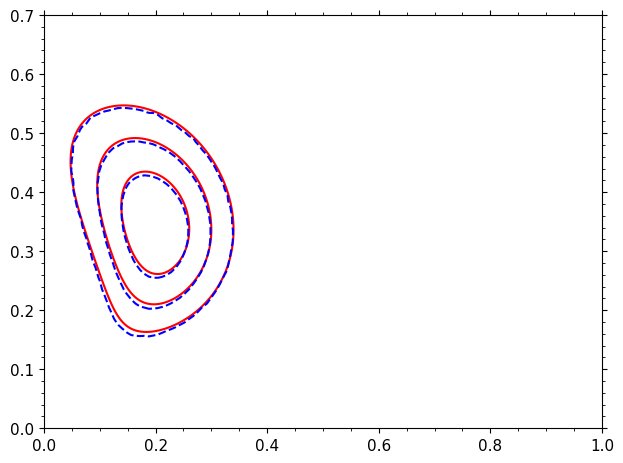

In [24]:
plt.contour(X, Y, n2ll, levels=n2ll_2d, colors='r', linestyles='-')
plt.contour(Xh, Yh, nh.T, levels=levels, colors='b', linestyles='--')

### An aside on plotting

My method of drawing the contours shown above is a bit laboured. Instead we can make use of a nice package for this called `corner`.
You'll make more use of this when it comes to the Bayesian part of the course, where you will often have a posterior distribution you want to draw the contours of.

So I'll use `corner` to make the plot of the bootstrap sample above and then overlay the likelihood contours

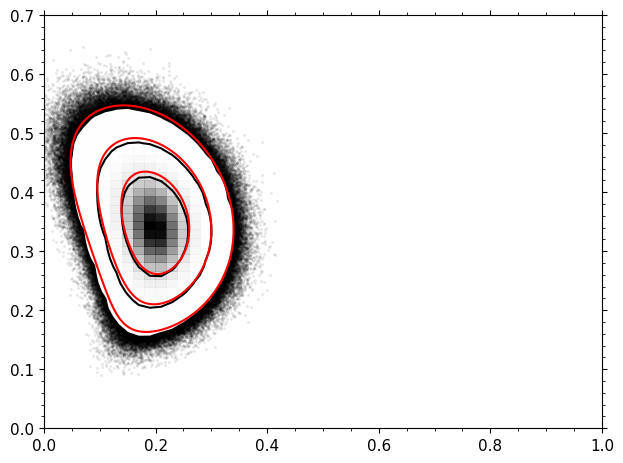

In [25]:
fig, ax = plt.subplots()

xy = np.column_stack((x_sample,y_sample))
corner.hist2d(x_sample, y_sample, bins=50, range=((0,1),(0,0.7)), levels=chi2.cdf([1,4,9],1), ax=ax)
ax.contour(X, Y, n2ll, levels=n2ll_2d, colors='r', linestyles='-')

### c) What about a 3D measurement?

Now let's think about what happens if we make a 3D measurement. Let's pretend I've made a simulataneous measurement of $r$, $\theta$ and $\beta$. We'll asume the same uncertainties as above, i.e.:

$$
\beta = (22\pm 4)^\circ, \; \theta = (60\pm 7)^\circ \; \text{and} \; r = 0.40 \pm 0.05
$$

with a correlation matrix of

$$
 \begin{pmatrix} 1 & -0.2 & 0.3 \\ -0.2 & 1 & 0.4 \\ 0.3 & 0.4 & 1 \end{pmatrix}
$$

In [26]:
# build the multivariate normal pdf
means = [beta_meas[0], theta_meas[0], r_meas[0]]
errors = [beta_meas[1], theta_meas[1], r_meas[1]]
corr = np.array( [ [1, -0.2, 0.3],
                   [-0.2, 1, 0.4],
                   [0.3, 0.4, 1 ]
                 ] )
covariance = np.outer(errors, errors) * corr

pdf = mvn(means, covariance)

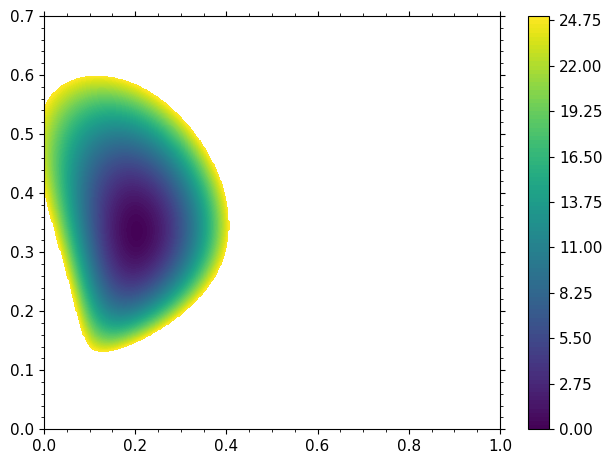

In [27]:
# do the same as before for likelihood

grid_point_pred = np.column_stack((beta_pred.flatten(), theta_pred.flatten(), r_pred.flatten() ))

nll_min = mvn.logpdf(means, means, covariance)
nll_point = mvn.logpdf(grid_point_pred, means, covariance)
nll_point = nll_point.reshape(X.shape)

n2ll = -2 * (nll_point - nll_min)

# mask points with large values
n2ll_plot = n2ll.copy()
n2ll_plot[n2ll_plot>25] = None

cb = plt.contourf(X, Y, n2ll_plot, levels=100)
plt.colorbar(cb)

Lovely stuff. But where do we draw the contours now? Is this still at the "2D" values, $-2\Delta\ln L = 2.30, 6.18, 11.83$ etc.? Or should we now be drawing them at the 3D equivalent values?

Well first let's run the toy method check and perhaps the answer will be illuminated then.

It's quite straightforward for us to generate a sample of 3D values (from the multivariate normal) but of course to plot them in the $(x,y)$ space we have to convert these to values in $(x,y)$. Typically this is not analytically possible because conversion from a 2D space to a 3D space is not generally invertible. Instead we will have to fit our generated values of $(\beta, \theta, r)$ back for $(x,y)$.

The process of performing this fit reduces the dimensionality from 3 down to 2. So what we'll see is that actually the contours are still drawn at the 2D equivalent (this fitting process means we actually now still only have **two degrees of freedom**).

The same is true if we draw the likelihood in 2D of a higher dimensional space. We typically will then "profile" the likelihood by fitting at each scan point for the other parameter(s). This again reduces the dimensionality down to 2.

Note the block below is quite slow, because for every point we fit back for x, y. So I try to make it more efficient using Parallel processing.

In [28]:
rvs = pdf.rvs(size=1000000)

xy_samples = []
def solve_xy(b_val, t_val, r_val):

    def n2ll_xy(xy):
        x, y = xy
        b = beta_func(x, y)
        t = theta_func(x, y)
        r = r_func(x, y)
    
        obs = [b_val, t_val, r_val]
        exp = np.column_stack([b, t, r])
        
        return -2 * mvn.logpdf(exp, obs, covariance)
    
    res = minimize(n2ll_xy, x0=[0.2, 0.3], bounds=([0,1],[0,1]))
    
    if res.success:
        return res.x
    else:
        return None

# the laptop begins to whirr...

results = Parallel(n_jobs=-1)(
    delayed(solve_xy)(b, t, r) for (b, t, r) in tqdm(rvs)
)
    
xy_samples = np.array([res for res in results if res is not None])

100%|██████████| 1000000/1000000 [07:43<00:00, 2155.32it/s]


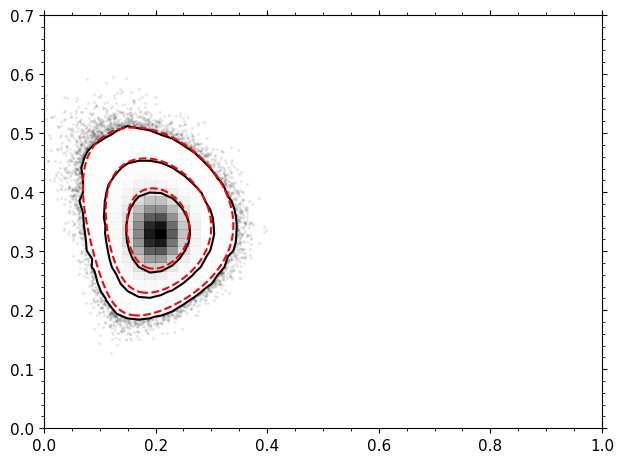

In [29]:
fig, ax = plt.subplots()
corner.hist2d(xy_samples[:,0], xy_samples[:,1], bins=50, range=((0,1),(0,0.7)), levels=chi2.cdf([1,4,9],1), ax=ax)
cf = ax.contour(X, Y, n2ll, levels=n2ll_2d, colors='r', linestyles='--' )

## The 3D vs 3D comparison for completeness

Just for completeness let's look at what happens when we compare the 3D sample to the 3D likelihood and where those contours should be drawn.

Our 3D model is that of $(\beta, \theta, r)$. What I'll do is make a corner plot showing the 2D and 1D distributions of bootstrap samples (these are essentially the marginal distributions). For the 2D ones I'll draw the contours containing $68.3\%$, $95.4\%$ and $99.7\%$ (using `corner.hist2d`'s `levels` argument). For the 1D ones I will do the same (draw lines which contain $68.3\%$, $95.4\%$ and $99.7\%$). You'll notice these lines don't join up with the contours.

Then I will overlay the **profile likelihood** on these. In the 1D case I profile over the other two parameters (which is then equivalent to having 1 d.o.f) and thus we'll see that to get the right probability content the intervals are found at $-2\Delta\ln L=1, 4, 9$. In the 2D case we only profile over the one other parameter and thus the correct contours are drawn at $-2\Delta\ln L=2.30, 6.18, 11.83$

Before doing that I will define a little function which given a 1D likelihood scan finds the interval for a given value of $-2\Delta\ln L$ (there's probably a package which does this)

In [30]:
def read_error_from_1d_n2ll(x, n2ll, levels=[1], xmin=None):
    if xmin is None:
        xmin = x[np.argmin(n2ll)]
    x_below = x[x<xmin]
    n2ll_below = n2ll[x<xmin]
    f_below = interp1d(n2ll_below, x_below)
    
    x_above = x[x>xmin]
    n2ll_above = n2ll[x>xmin]
    f_above = interp1d(n2ll_above, x_above)
    
    res = []
    for level in levels:
        lower = f_below(level)
        upper = f_above(level)
        res.append( [lower, upper] )
    
    return res
    

/Users/jacobtutt/.pyenv/versions/3.10.9/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/jacobtutt/.pyenv/versions/3.10.9/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


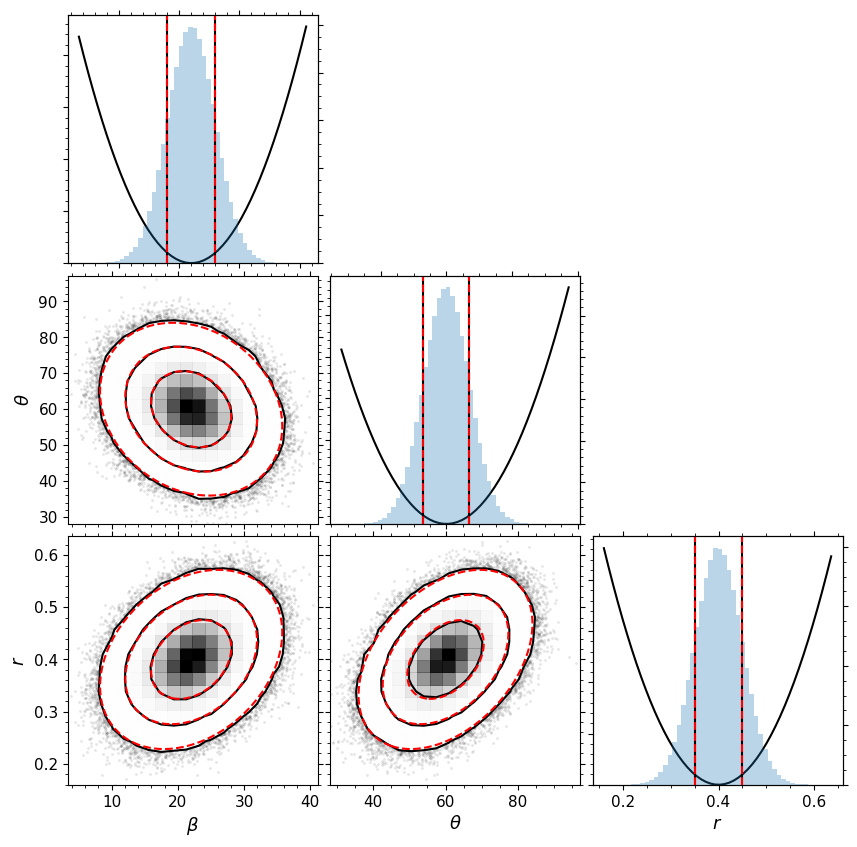

In [31]:
# create spaces for beta, theta and r
b_space = np.linspace(rvs[:,0].min(), rvs[:,0].max(), 50)
t_space = np.linspace(rvs[:,1].min(), rvs[:,1].max(), 50)
r_space = np.linspace(rvs[:,2].min(), rvs[:,2].max(), 50)

# define the negative log likelihood for three parameters
# so we can find the value at the global minimum

def n2ll(beta, theta, r):
    
    exp = np.column_stack([beta, theta, r])
        
    return -2 * mvn.logpdf(exp, means, covariance)

# find global minimum
def z_func(pars):
    return n2ll(pars[0], pars[1], pars[2])

z0 = [beta_meas[0], theta_meas[0], r_meas[0]]
bound = [ [b_space.min(), b_space.max()], [t_space.min(), t_space.max()], [r_space.min(), r_space.max()] ]
res = minimize(z_func, z0, bounds=bound)
n2ll_min = res.fun

# make the figure
fig, ax = plt.subplots(3, 3, figsize=(10,10), gridspec_kw=dict(hspace=0.05, wspace=0.05))

# iterate over the 2D combinations
for i, (xpar, xspace) in enumerate(zip([r'$\beta$', r'$\theta$', r'$r$'], [b_space, t_space, r_space])):
    for j, (ypar, yspace) in enumerate(zip([r'$\beta$', r'$\theta$', r'$r$'], [b_space, t_space, r_space])):
        
        # styling
        if i != 2: # no xticks or labels except on bottom row
            ax[i,j].set_xticklabels([])
            ax[i,j].set_xlabel("")
        if j != 0 or i <= j:  # no yticks or labels except on leftmost column or above diagonal
            ax[i, j].set_yticklabels([])
            ax[i, j].set_ylabel("")
        
        # dont do above the diagonal
        if i>j:
            ax[j,i].set_visible(False)
            continue
            
        # along the diagonal do the 1D plots
        elif i==j:
            # something to store the likelihood values
            Z_profile = np.zeros_like(xspace)
            
            # scan points and minimise (profile) the likelihood at each point
            for ii in range(xspace.shape[0]):
                x = xspace[ii]
                
                # this is a very **nasty** way of coding it (please forgive me)
                # (if this was a C1 coursework I would get penalised for this mess)
                
                # beta
                if i==0: 
                    z_func = lambda pars: n2ll(x, pars[0], pars[1])  # noqa: E731
                    z0 = [theta_meas[0], r_meas[0]]
                    bound = [ [t_space.min(), t_space.max()], [r_space.min(), r_space.max()] ]
                    
                # theta
                elif i==1:
                    z_func = lambda pars: n2ll(pars[0], x, pars[1])  # noqa: E731
                    z0 = [beta_meas[0], r_meas[0]]
                    bound = [ [b_space.min(), b_space.max()], [r_space.min(), r_space.max()] ]
                    
                # r
                elif i==2:
                    z_func = lambda pars: n2ll(pars[0], pars[1], x)  # noqa: E731
                    z0 = [beta_meas[0], theta_meas[0]]
                    bound = [ [b_space.min(), b_space.max()], [t_space.min(), t_space.max()] ]
                    
                res = minimize(z_func, x0=z0, bounds=bound)
                Z_profile[ii] = res.fun - n2ll_min
            
            
            # plot the density of toys
            tax = ax[i,i].twinx()
            tax.set_yticklabels([])
            tax.hist(rvs[:,i], bins=50, fc='0.25', density=True, alpha=0.3, range=(xspace.min(), xspace.max()))
            # find the 1D intervals of the toys
            lq = (1-chi2.cdf(1,1))/2
            hq = 1-lq
            lower, upper = np.percentile(rvs[:,i], [lq*100, hq*100])
            tax.axvline(lower, c='k', ls='-')
            tax.axvline(upper, c='k', ls='-')
            
            # plot the likelihood
            ax[i,i].plot(xspace, Z_profile, c='k')
            ax[i,i].set_ylim(bottom=0)
            # find the 1D intervals of the toys
            interval = read_error_from_1d_n2ll(xspace, Z_profile)[0]
            tax.axvline(interval[0], c='r', ls='--')
            tax.axvline(interval[1], c='r', ls='--')
              
            if i==2:
                ax[i,j].set_xlabel(xpar)
         
        # below the diagonal do the 2D plots
        else:
            X, Y = np.meshgrid(xspace, yspace)
            
            # something to store the likelihood values
            Z_profile = np.zeros_like(X)
            
            # scan points and minimise (profile) the likelihood at each point
            for ii in range(X.shape[0]):
                for jj in range(X.shape[1]):
                    x = X[ii,jj]
                    y = Y[ii,jj]
                    
                    # this is a very **nasty** way of coding it (please forgive me)
                    # (if this was a C1 coursework I would get penalised for this mess)
                
                    # beta
                    if i==0 and j==1:
                        z_func = lambda r: n2ll(x, y, r)  # noqa: E731
                        z0 = r_meas[0]
                        bound = [r_space.min(), r_space.max()]
                        
                    # theta
                    elif i==0 and j==2:
                        z_func = lambda t: n2ll(x, t, y)  # noqa: E731
                        z0 = theta_meas[0]
                        bound = [t_space.min(), t_space.max()]
                        
                    # r
                    elif i==1 and j==2:
                        z_func = lambda b: n2ll(b, x, y)  # noqa: E731
                        z0 = beta_meas[0]
                        bound = [b_space.min(), b_space.max()]
                
                    res = minimize(z_func, x0=z0, bounds=[bound])
                    Z_profile[ii,jj] = res.fun - n2ll_min
                    
            
            # plot the distribution of toys and contours using `corner`
            corner.hist2d(rvs[:,i], rvs[:,j], levels=chi2.cdf([1,4,9],1), ax=ax[j,i])
        
            # plot the likelihood scan and draw contours at 2D levels
            ax[j,i].contour(X, Y, Z_profile, levels=n2ll_2d, colors='r', linestyles='--')
            ax[j,i].set_xlabel(xpar)
            ax[j,i].set_ylabel(ypar)
        


### Summary


 - In general if you perform a likelihood scan (profile likleihood) in 1D then the intervals which contain 68.3%, 95.4%, 99.7% etc. correspond to where $-2\Delta \ln L$ crosses 1, 4, 9 etc. (which come from a $\chi^2$ distribution with **1 d.o.f**)
 - In **nearly** all cases if you perform a likelihood scan (profile likelihood) in 2D then the intervals which contain 68.3%, 95.4%, 99.7% etc. correspond to where $-2\Delta \ln L$ crosses 2.30, 6.18, 11.83 etc. (which come from a $\chi^2$ distribution with **2 d.o.f**)
     - the only exception is when the measurement itself is one-dimensional (a single value being projected into a higher dimensional space). In that case the contours should be drawn at the 1d point.
     - even for higher dimensional measurements of likelihoods in order to project down into 2d we effectively lose the extra degrees of freedom (in the marginalisation, profiling process)
     
 - We don't need to worry about where the 3D or 4D contours would be because we cannot plot in anything higher than 2 dimensions